# Model Evaluation & Improvement — 2026-03-03

## Goal

Systematically benchmark the baseline model and try to beat it with cross-regional learning.

## Structure

1. **Setup** — imports, paths, load data
2. **Data preparation** — extract per-region train/test splits
3. **Model 1: Baseline** — per-region mean-velocity extrapolation (temporal holdout)
4. **Model 2: Cross-regional linear regression** — learn velocity → velocity across all regions
5. **Comparison** — MAE, RMSE, bias, error distributions
6. **Helper functions** — reusable evaluation utilities

## Key design decisions

- **No external features** in this notebook — velocity only, keeping it maximally simple
- **Temporal holdout**: for regions with ≥3 timestamps, train on all but last, test on last
- **Self-contained**: loads from pre-saved parquet, no GeoPackage or DataHandler needed
- Cluster, distance-to-centerline, WFS features etc. are explicitly left for future notebooks

---

## 1. Setup

In [1]:
import sys
sys.path.insert(0, '../..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

import src.paths as PATHS
import src.constants as CONST

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)

DIST_COL = CONST.DISTANCE_TO_EROSION_BORDER

print('✅ Imports OK')

✅ Imports OK


## 2. Load Data

In [2]:
# Processed erosion data: (location_id, dtm_date) → distance_to_erosion_border
# Saved from baseline_model_full_dataset.ipynb
PARQUET_PATH = PATHS.DATA_DIR / '02_processed/erosion/processed_erosion_data.parquet'

processed = pd.read_parquet(PARQUET_PATH)
processed.index.names = ['location_id', 'year']

print(f'Loaded processed_erosion_data')
print(f'  Shape:     {processed.shape}')
print(f'  Locations: {processed.index.get_level_values(0).nunique():,}')
print(f'  Years:     {sorted(processed.index.get_level_values(1).unique())}')
print(f'\nSample:')
print(processed.head(6))

Loaded processed_erosion_data
  Shape:     (30228, 2)
  Locations: 10,484
  Years:     [2015, 2016, 2017, 2020, 2021, 2022, 2024, 2025]

Sample:
                          distance_to_erosion_border  \
location_id         year                               
ijssel1_l_0000_0010 2017                   76.083333   
                    2025                   77.083333   
ijssel1_l_0010_0020 2017                   94.305351   
                    2022                   94.973000   
                    2025                   94.806087   
ijssel1_l_0020_0030 2017                  117.583333   

                          timesteps_since_last_measurement  
location_id         year                                    
ijssel1_l_0000_0010 2017                               1.0  
                    2025                               8.0  
ijssel1_l_0010_0020 2017                               1.0  
                    2022                               5.0  
                    2025                

## 2b. Data Exploration — Temporal coverage by cluster

Which years have measurements, and how many regions per year, broken down by river cluster?

Number of regions with a measurement per cluster per year
(0 = cluster has no data for that year)

year       2015  2016  2017  2020  2021  2022  2024  2025
cluster                                                  
ijssel1       0     0  2116     0     0  2118     0  2074
ijssel2       0     0   347     0     0   348     0   361
maas1         0   142     0     0   141     0   141     0
maas2         0   347     0     0   342     0   311     0
maas3         0  3202     0     0  3187     0  3180     0
nederrijn  2225     0     0  2236     0     0  1638     0
rijn       1965     0     0  1953     0     0  1854     0
TOTAL      4190  3691  2463  4189  3670  2466  7124  2435


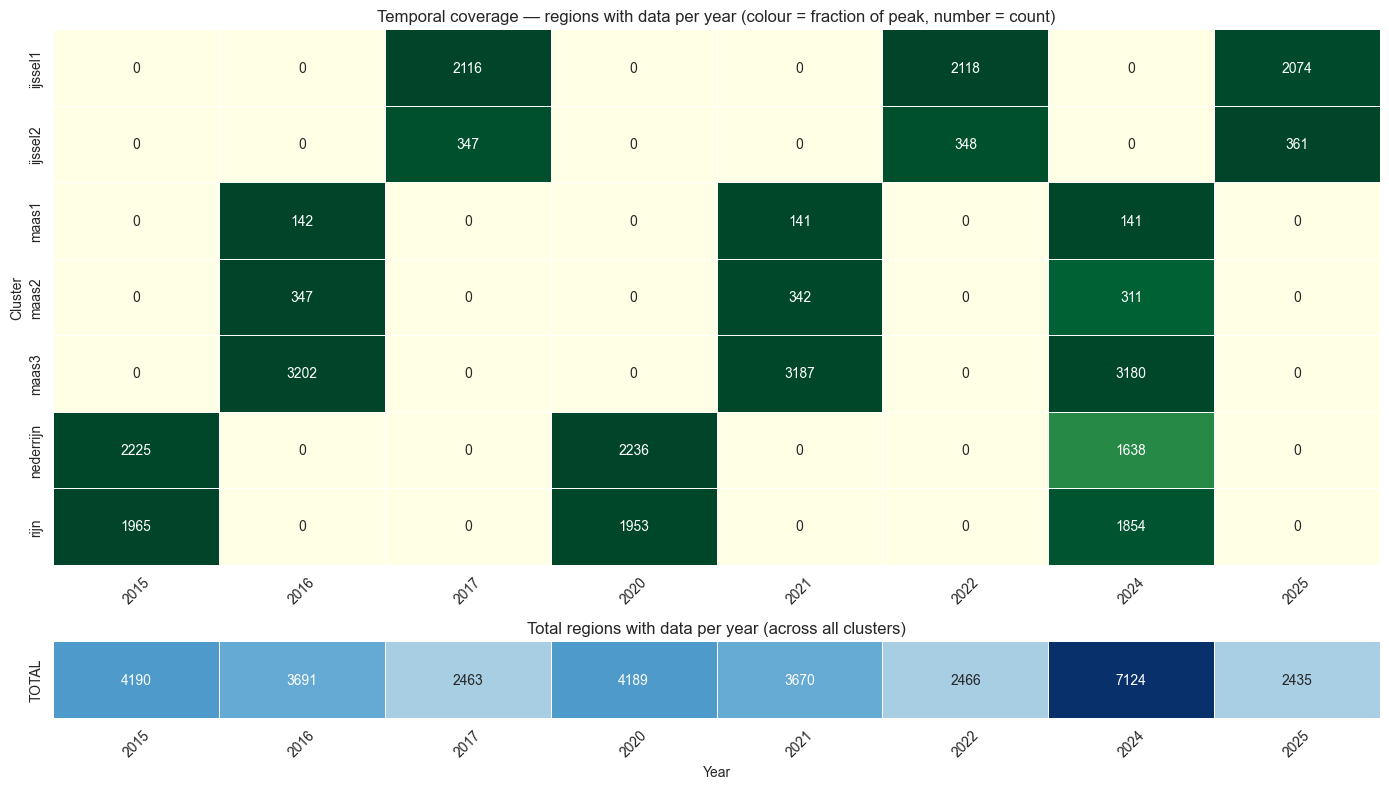


Distinct measurement-year fingerprints per cluster:

  ijssel1:
    [2017, 2022, 2025]  →  2,054 regions
    [2017, 2022]  →  49 regions
    [2017, 2025]  →  8 regions

  ijssel2:
    [2017, 2022, 2025]  →  343 regions
    [2025]  →  10 regions
    [2022, 2025]  →  5 regions

  maas1:
    [2016, 2021, 2024]  →  141 regions
    [2016]  →  1 regions

  maas2:
    [2016, 2021, 2024]  →  298 regions
    [2016, 2021]  →  32 regions
    [2021]  →  11 regions

  maas3:
    [2016, 2021, 2024]  →  3,129 regions
    [2016, 2021]  →  29 regions
    [2021, 2024]  →  23 regions

  nederrijn:
    [2015, 2020, 2024]  →  1,609 regions
    [2015, 2020]  →  599 regions
    [2020, 2024]  →  17 regions

  rijn:
    [2015, 2020, 2024]  →  1,828 regions
    [2015, 2020]  →  109 regions
    [2015]  →  19 regions


In [11]:
CLUSTERS = ['ijssel1', 'ijssel2', 'maas1', 'maas2', 'maas3', 'nederrijn', 'rijn']

def get_cluster(location_id: str) -> str:
    for c in CLUSTERS:
        if location_id.startswith(c):
            return c
    return 'other'


# Build presence table: for every (location_id, year) row that exists, mark it
coverage = processed.reset_index()[['location_id', 'year']].copy()
coverage['cluster'] = coverage['location_id'].map(get_cluster)

# ── 1. Total regions-per-year (all clusters combined) ────────────────────────
total_by_year = coverage.groupby('year')['location_id'].nunique().rename('total')

# ── 2. Regions-per-year per cluster ──────────────────────────────────────────
cluster_year = (
    coverage.groupby(['cluster', 'year'])['location_id']
    .nunique()
    .unstack(level='year', fill_value=0)
)

# Add total row
cluster_year.loc['TOTAL'] = total_by_year.reindex(cluster_year.columns, fill_value=0)

print('Number of regions with a measurement per cluster per year')
print('(0 = cluster has no data for that year)\n')
print(cluster_year.to_string())

# ── 3. Heatmap ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8),
                          gridspec_kw={'height_ratios': [len(cluster_year) - 1, 1]})

# Per-cluster heatmap (exclude TOTAL row)
cluster_data = cluster_year.drop('TOTAL')
total_data   = cluster_year.loc[['TOTAL']]

# Normalise per row so colour = fraction of max — makes sparse clusters visible
cluster_norm = cluster_data.div(cluster_data.max(axis=1).replace(0, 1), axis=0)

sns.heatmap(
    cluster_norm,
    ax=axes[0],
    cmap='YlGn',
    linewidths=0.5,
    linecolor='white',
    annot=cluster_data,          # show raw counts in each cell
    fmt='d',
    cbar=False,
    vmin=0, vmax=1,
)
axes[0].set_title('Temporal coverage — regions with data per year (colour = fraction of peak, number = count)')
axes[0].set_xlabel('')
axes[0].set_ylabel('Cluster')
axes[0].tick_params(axis='x', rotation=45)

# Total row — separate axis so we can use a different colour
sns.heatmap(
    total_data / total_data.max(axis=1).values[0],
    ax=axes[1],
    cmap='Blues',
    linewidths=0.5,
    linecolor='white',
    annot=total_data,
    fmt='d',
    cbar=False,
    vmin=0, vmax=1,
)
axes[1].set_title('Total regions with data per year (across all clusters)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ── 4. Which unique year-combinations exist per cluster? ─────────────────────
print('\nDistinct measurement-year fingerprints per cluster:')
for cluster, group in coverage.groupby('cluster'):
    # Find most common set of years across regions in this cluster
    year_sets = group.groupby('location_id')['year'].apply(frozenset)
    top = year_sets.value_counts().head(3)
    print(f'\n  {cluster}:')
    for years_combo, count in top.items():
        print(f'    {sorted(years_combo)}  →  {count:,} regions')

## 3. Data Preparation — Per-region train/test split

For each region with ≥ 3 timestamps:
- **Train**: all timestamps except the last
- **Test**: the last timestamp

From the training data we derive:
- `velocity_train`: mean Δdist/Δt across consecutive training pairs

From train → test we derive:
- `velocity_test`: actual Δdist/Δt in the held-out period (ground truth)
- `actual_dist`: actual distance at the test timestamp (used to compute distance error)

In [10]:
def compute_mean_velocity(years, dists):
    """Compute mean velocity (m/yr) across consecutive (year, dist) pairs."""
    speeds = [
        (dists[i+1] - dists[i]) / (years[i+1] - years[i])
        for i in range(len(years) - 1)
    ]
    return float(np.mean(speeds))


records = []

for location_id, region_data in processed.groupby(level=0):
    region_sorted = region_data.sort_index()
    years = region_sorted.index.get_level_values(1).tolist()
    dists = region_sorted[DIST_COL].tolist()

    if len(years) < 3:
        continue  # need ≥2 train timestamps + 1 test timestamp

    # Train / test split
    train_years, test_year = years[:-1], years[-1]
    train_dists, test_dist = dists[:-1], dists[-1]

    velocity_train = compute_mean_velocity(train_years, train_dists)

    # Actual velocity in held-out period (last_train → test)
    years_ahead    = test_year - train_years[-1]
    velocity_test  = (test_dist - train_dists[-1]) / years_ahead

    # What baseline model would predict for the test distance
    predicted_dist_baseline = train_dists[-1] + velocity_train * years_ahead

    records.append({
        'location_id':              location_id,
        'n_train_timestamps':       len(train_years),
        'train_years':              train_years,
        'last_train_year':          train_years[-1],
        'last_train_dist':          train_dists[-1],
        'test_year':                test_year,
        'years_ahead':              years_ahead,
        'velocity_train':           velocity_train,  # feature for cross-regional model
        'velocity_test':            velocity_test,   # target for cross-regional model
        'actual_dist':              test_dist,
        'predicted_dist_baseline':  predicted_dist_baseline,
    })

eval_df = pd.DataFrame(records)

print(f'Regions with ≥3 timestamps (evaluable): {len(eval_df):,}')
print(f'Regions with only 2 timestamps (skipped): {processed.index.get_level_values(0).nunique() - len(eval_df):,}')
print(f'\nYears ahead distribution:')
print(eval_df['years_ahead'].value_counts().sort_index())
print(f'\nSample:')
print(eval_df[['location_id','velocity_train','velocity_test','actual_dist','predicted_dist_baseline','years_ahead']].head(6).round(3))

Regions with ≥3 timestamps (evaluable): 9,402
Regions with only 2 timestamps (skipped): 1,082

Years ahead distribution:
years_ahead
3    5965
4    3437
Name: count, dtype: int64

Sample:
           location_id  velocity_train  velocity_test  actual_dist  \
0  ijssel1_l_0010_0020           0.134         -0.056       94.806   
1  ijssel1_l_0020_0030           3.750         -5.972      118.417   
2  ijssel1_l_0050_0056          -0.033         -0.000       40.500   
3  ijssel1_l_0056_0060           0.050          3.944       47.000   
4  ijssel1_l_0060_0070          -0.417          0.111       53.746   
5  ijssel1_l_0070_0080           0.000          0.000       38.139   

   predicted_dist_baseline  years_ahead  
0                   95.374            3  
1                  147.583            3  
2                   40.400            3  
3                   35.317            3  
4                   52.160            3  
5                   38.139            3  


## 3b. Actual bank movement — putting MAE in context

How much does the river bank actually move?

- **Train phase**: total movement (first → last training timestamp)
- **Test phase**: movement in the held-out period (last train → test timestamp)

If the test-phase movement is of the same order as the MAE, the model has little signal.  
If it is much larger, the model is at least getting the right ballpark.

── Train phase ──────────────────────────────────────
  Span (years):     mean=5.0  median=5  range=[5, 5]
  |Movement| (m):   mean=5.96  median=1.00  p90=14.02
  Velocity (m/yr):  mean=-0.132  median=0.017  std=3.274
  Virtually stable (<1m movement): 50.1% of regions

── Test phase ──────────────────────────────────────
  Span (years):     mean=3.4  median=3  range=[3, 4]
  |Movement| (m):   mean=7.04  median=1.00  p90=15.27
  Velocity (m/yr):  mean=0.873  median=0.028  std=5.222
  Virtually stable (<1m movement): 50.3% of regions



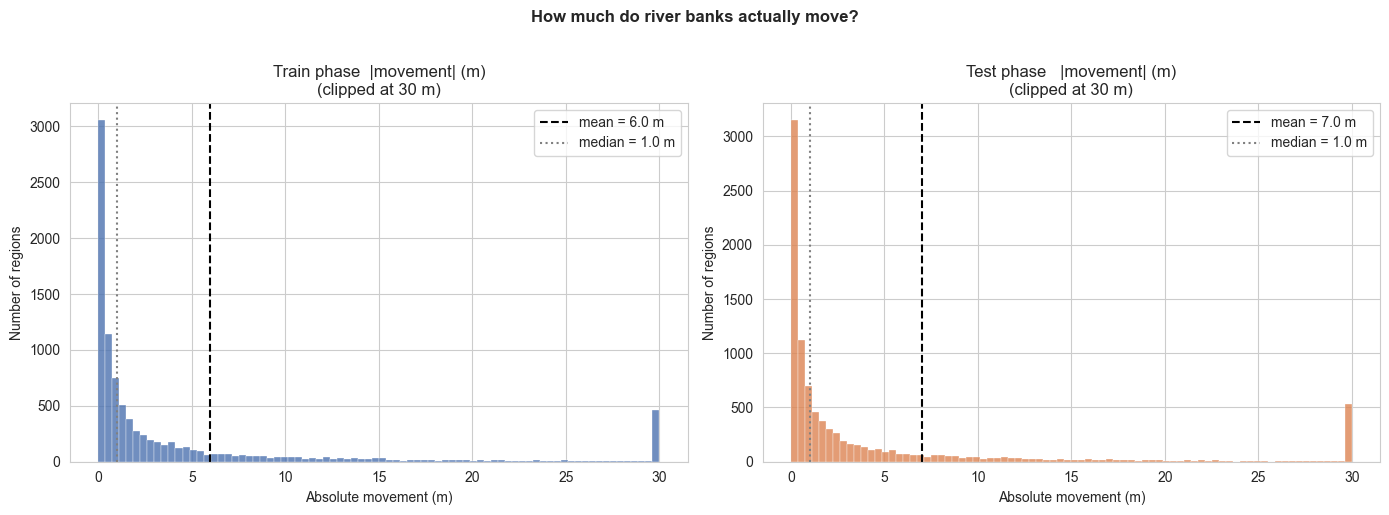


Mean absolute movement per cluster:


,n_regions,train |Δdist| mean (m),test |Δdist| mean (m),test velocity mean (m/yr)
cluster,,,,
ijssel1,2054,2.57,3.68,0.39
ijssel2,343,2.04,2.32,-0.02
maas1,141,1.10,0.95,0.07
maas2,298,8.60,8.79,1.86
maas3,3129,2.64,2.53,0.13
nederrijn,1609,6.47,5.13,0.04
rijn,1828,15.67,21.28,3.48



── MAE in context ───────────────────────────────────
  Naive "no change" baseline MAE  : 7.039 m  (predict last known dist)
  Our baseline model MAE          : 10.878 m  (154.5% of naive)
  LR cross-regional MAE           : 6.798 m  (96.6% of naive)

  Mean actual test-phase movement : 7.039 m
  Median actual test-phase movement: 1.000 m


In [12]:
# Compute movement for each region from the full processed data
movement_records = []

for location_id, region_data in processed.groupby(level=0):
    region_sorted = region_data.sort_index()
    years = region_sorted.index.get_level_values(1).tolist()
    dists = region_sorted[DIST_COL].tolist()

    if len(years) < 3:
        continue

    train_years, test_year = years[:-1], years[-1]
    train_dists, test_dist = dists[:-1], dists[-1]

    train_span = train_years[-1] - train_years[0]  # years in train period

    movement_records.append({
        'location_id':         location_id,
        'cluster':             get_cluster(location_id),
        # Train phase
        'train_movement_m':    train_dists[-1] - train_dists[0],       # signed
        'train_abs_movement_m':abs(train_dists[-1] - train_dists[0]),  # absolute
        'train_span_yr':       train_span,
        'train_velocity_myr':  (train_dists[-1] - train_dists[0]) / train_span if train_span > 0 else np.nan,
        # Test phase
        'test_movement_m':     test_dist - train_dists[-1],
        'test_abs_movement_m': abs(test_dist - train_dists[-1]),
        'test_span_yr':        test_year - train_years[-1],
        'test_velocity_myr':   (test_dist - train_dists[-1]) / (test_year - train_years[-1]),
    })

mov = pd.DataFrame(movement_records)

# ── Summary stats ─────────────────────────────────────────────────────────────
for phase, col_abs, col_vel, col_span in [
    ('Train phase', 'train_abs_movement_m', 'train_velocity_myr', 'train_span_yr'),
    ('Test phase',  'test_abs_movement_m',  'test_velocity_myr',  'test_span_yr'),
]:
    print(f'── {phase} ──────────────────────────────────────')
    print(f'  Span (years):     mean={mov[col_span].mean():.1f}  '
          f'median={mov[col_span].median():.0f}  '
          f'range=[{mov[col_span].min():.0f}, {mov[col_span].max():.0f}]')
    print(f'  |Movement| (m):   mean={mov[col_abs].mean():.2f}  '
          f'median={mov[col_abs].median():.2f}  '
          f'p90={mov[col_abs].quantile(0.9):.2f}')
    print(f'  Velocity (m/yr):  mean={mov[col_vel].mean():.3f}  '
          f'median={mov[col_vel].median():.3f}  '
          f'std={mov[col_vel].std():.3f}')
    stable = (mov[col_abs] < 1).mean() * 100
    print(f'  Virtually stable (<1m movement): {stable:.1f}% of regions')
    print()

# ── Distributions ─────────────────────────────────────────────────────────────
CLIP_M = 30   # clip extreme movers for readability
BINS   = 80

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, col, title, color in [
    (axes[0], 'train_abs_movement_m', 'Train phase  |movement| (m)', '#4c72b0'),
    (axes[1], 'test_abs_movement_m',  'Test phase   |movement| (m)', '#dd8452'),
]:
    data_clipped = mov[col].clip(0, CLIP_M)
    ax.hist(data_clipped, bins=BINS, color=color, alpha=0.8, edgecolor='white', linewidth=0.3)
    mean_val   = mov[col].mean()
    median_val = mov[col].median()
    ax.axvline(mean_val,   color='black',  linestyle='--', linewidth=1.5, label=f'mean = {mean_val:.1f} m')
    ax.axvline(median_val, color='grey',   linestyle=':',  linewidth=1.5, label=f'median = {median_val:.1f} m')
    ax.set_xlabel('Absolute movement (m)')
    ax.set_ylabel('Number of regions')
    ax.set_title(f'{title}\n(clipped at {CLIP_M} m)')
    ax.legend()

plt.suptitle('How much do river banks actually move?', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Per-cluster breakdown ──────────────────────────────────────────────────────
print('\nMean absolute movement per cluster:')
cluster_summary = mov.groupby('cluster').agg(
    n              = ('location_id', 'count'),
    train_abs_mean = ('train_abs_movement_m', 'mean'),
    test_abs_mean  = ('test_abs_movement_m',  'mean'),
    test_vel_mean  = ('test_velocity_myr',    'mean'),
).round(2)
cluster_summary.columns = ['n_regions', 'train |Δdist| mean (m)', 'test |Δdist| mean (m)', 'test velocity mean (m/yr)']
display(cluster_summary)

# ── Contextualise MAE ─────────────────────────────────────────────────────────
baseline_mae = 10.878   # update if you re-run the model cells above
lr_mae       = 6.798

test_mean  = mov['test_abs_movement_m'].mean()
test_med   = mov['test_abs_movement_m'].median()
naive_mae  = mov['test_abs_movement_m'].mean()   # predicting zero change = MAE = |actual movement|

print('\n── MAE in context ───────────────────────────────────')
print(f'  Naive "no change" baseline MAE  : {naive_mae:.3f} m  (predict last known dist)')
print(f'  Our baseline model MAE          : {baseline_mae:.3f} m  ({baseline_mae/naive_mae*100:.1f}% of naive)')
print(f'  LR cross-regional MAE           : {lr_mae:.3f} m  ({lr_mae/naive_mae*100:.1f}% of naive)')
print(f'\n  Mean actual test-phase movement : {test_mean:.3f} m')
print(f'  Median actual test-phase movement: {test_med:.3f} m')

## 4. Helper Functions — Evaluation

Centralised so every model is evaluated identically.

In [4]:
def evaluate_distance_predictions(actual_dist, predicted_dist, model_name='Model'):
    """
    Compute and print standard error metrics for distance predictions.

    Parameters
    ----------
    actual_dist    : array-like of actual distances (m)
    predicted_dist : array-like of predicted distances (m)
    model_name     : label for printing

    Returns
    -------
    dict of metrics
    """
    errors     = np.array(predicted_dist) - np.array(actual_dist)
    abs_errors = np.abs(errors)

    metrics = {
        'model':    model_name,
        'n':        len(errors),
        'mae':      float(np.mean(abs_errors)),
        'rmse':     float(np.sqrt(np.mean(errors**2))),
        'bias':     float(np.mean(errors)),
        'median_ae':float(np.median(abs_errors)),
        'p90_ae':   float(np.quantile(abs_errors, 0.9)),
        'within_1m':  float(np.mean(abs_errors <= 1)),
        'within_5m':  float(np.mean(abs_errors <= 5)),
        'within_10m': float(np.mean(abs_errors <= 10)),
    }

    print(f'\n--- {model_name} (n={metrics["n"]:,}) ---')
    print(f'  MAE:              {metrics["mae"]:>8.3f} m')
    print(f'  RMSE:             {metrics["rmse"]:>8.3f} m')
    print(f'  Bias:             {metrics["bias"]:>8.3f} m  ({"over" if metrics["bias"]>0 else "under"}-predicts erosion)')
    print(f'  Median AE:        {metrics["median_ae"]:>8.3f} m')
    print(f'  90th pct AE:      {metrics["p90_ae"]:>8.3f} m')
    print(f'  Within  1 m:      {metrics["within_1m"]*100:>6.1f}%')
    print(f'  Within  5 m:      {metrics["within_5m"]*100:>6.1f}%')
    print(f'  Within 10 m:      {metrics["within_10m"]*100:>6.1f}%')
    return metrics


def plot_error_distributions(results_list, clip_abs=50, clip_signed=30):
    """
    Plot absolute and signed error distributions for a list of model result dicts.
    Each dict: {'label': str, 'actual': array, 'predicted': array, 'color': str}
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for r in results_list:
        errors     = np.array(r['predicted']) - np.array(r['actual'])
        abs_errors = np.abs(errors)
        mae = np.mean(abs_errors)

        pd.Series(abs_errors).clip(0, clip_abs).hist(
            bins=60, ax=axes[0], alpha=0.6, color=r.get('color','steelblue'), label=f"{r['label']} (MAE={mae:.1f}m)")
        pd.Series(errors).clip(-clip_signed, clip_signed).hist(
            bins=60, ax=axes[1], alpha=0.6, color=r.get('color','steelblue'), label=r['label'])

    axes[0].set_title(f'Absolute error distribution (clipped at {clip_abs}m)')
    axes[0].set_xlabel('|predicted − actual| (m)')
    axes[0].legend()

    axes[1].axvline(0, color='black', linewidth=1)
    axes[1].set_title(f'Signed error distribution (clipped at ±{clip_signed}m)')
    axes[1].set_xlabel('predicted − actual (m)   [+ = over-predicted erosion]')
    axes[1].legend()

    plt.tight_layout()
    plt.show()


print('✅ Evaluation helpers defined.')

✅ Evaluation helpers defined.


## 5. Model 1: Baseline — Per-region mean velocity extrapolation

This is what `BaselineErosionModel` does: take the mean historical velocity for each region and extrapolate linearly. No cross-regional learning whatsoever.

In [5]:
print('=' * 55)
print('Model 1: Per-region mean-velocity extrapolation')
print('=' * 55)

metrics_baseline = evaluate_distance_predictions(
    actual_dist    = eval_df['actual_dist'],
    predicted_dist = eval_df['predicted_dist_baseline'],
    model_name     = 'Baseline (per-region mean velocity)',
)

# Error by years_ahead — does accuracy degrade with longer horizon?
print('\nMAE by prediction horizon (years ahead):')
horizon_mae = eval_df.copy()
horizon_mae['abs_error'] = (eval_df['predicted_dist_baseline'] - eval_df['actual_dist']).abs()
print(horizon_mae.groupby('years_ahead')['abs_error'].agg(['mean','median','count']).round(3))

Model 1: Per-region mean-velocity extrapolation

--- Baseline (per-region mean velocity) (n=9,402) ---
  MAE:                10.878 m
  RMSE:               29.810 m
  Bias:               -3.876 m  (under-predicts erosion)
  Median AE:           1.903 m
  90th pct AE:        24.514 m
  Within  1 m:        38.9%
  Within  5 m:        67.7%
  Within 10 m:        79.5%

MAE by prediction horizon (years ahead):
               mean  median  count
years_ahead                       
3             4.530   1.235   5965
4            21.894   4.855   3437


## 6. Model 2: Cross-regional linear regression on velocity

Can we learn a global relationship between training velocity and test velocity?

```
predicted_velocity_test = α + β × velocity_train
```

If β < 1 → fast-eroding banks tend to mean-revert (over-extrapolation is penalised).  
If β ≈ 1 → velocity is persistent; no improvement over baseline.  
If β > 1 → acceleration is systematic.

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold

# Features and target
X = eval_df[['velocity_train']].values
y = eval_df['velocity_test'].values

# Fit global model
lr = LinearRegression()
lr.fit(X, y)

print(f'Linear regression: velocity_test = {lr.intercept_:.4f} + {lr.coef_[0]:.4f} × velocity_train')
print(f'  α (intercept): {lr.intercept_:.4f} m/yr  (baseline drift when velocity_train = 0)')
print(f'  β (slope):     {lr.coef_[0]:.4f}          ({"mean-reversion" if lr.coef_[0] < 1 else "persistence/acceleration"})')

# Cross-validated R²
cv_r2 = cross_val_score(LinearRegression(), X, y, cv=KFold(5, shuffle=True, random_state=42), scoring='r2')
print(f'  CV R² (5-fold): {cv_r2.mean():.3f} ± {cv_r2.std():.3f}')

# Predict test distances using learned velocity
predicted_velocity_lr = lr.predict(X)
eval_df['predicted_dist_lr'] = (
    eval_df['last_train_dist'] + predicted_velocity_lr * eval_df['years_ahead']
)

print('\n' + '=' * 55)
print('Model 2: Cross-regional linear regression (velocity)')
print('=' * 55)
metrics_lr = evaluate_distance_predictions(
    actual_dist    = eval_df['actual_dist'],
    predicted_dist = eval_df['predicted_dist_lr'],
    model_name     = 'LR cross-regional (velocity_train → velocity_test)',
)

Linear regression: velocity_test = 0.7485 + -0.9386 × velocity_train
  α (intercept): 0.7485 m/yr  (baseline drift when velocity_train = 0)
  β (slope):     -0.9386          (mean-reversion)
  CV R² (5-fold): 0.343 ± 0.051

Model 2: Cross-regional linear regression (velocity)

--- LR cross-regional (velocity_train → velocity_test) (n=9,402) ---
  MAE:                 6.798 m
  RMSE:               15.992 m
  Bias:               -0.243 m  (under-predicts erosion)
  Median AE:           2.689 m
  90th pct AE:        13.788 m
  Within  1 m:         9.5%
  Within  5 m:        75.8%
  Within 10 m:        86.5%


## 7. Comparison

In [7]:
# Summary table
summary = pd.DataFrame([metrics_baseline, metrics_lr]).set_index('model')
display(summary[['mae','rmse','bias','median_ae','p90_ae','within_1m','within_5m','within_10m']].round(3))

# Improvement
mae_improvement = (metrics_baseline['mae'] - metrics_lr['mae']) / metrics_baseline['mae'] * 100
print(f'\nMAE improvement of LR over baseline: {mae_improvement:.1f}%')
print(f'  Baseline MAE: {metrics_baseline["mae"]:.3f} m')
print(f'  LR MAE:       {metrics_lr["mae"]:.3f} m')

,mae,rmse,bias,median_ae,p90_ae,within_1m,within_5m,within_10m
model,,,,,,,,
Baseline (per-region mean velocity),10.878,29.810,-3.876,1.903,24.514,0.389,0.677,0.795
LR cross-regional (velocity_train → velocity_test),6.798,15.992,-0.243,2.689,13.788,0.095,0.758,0.865



MAE improvement of LR over baseline: 37.5%
  Baseline MAE: 10.878 m
  LR MAE:       6.798 m


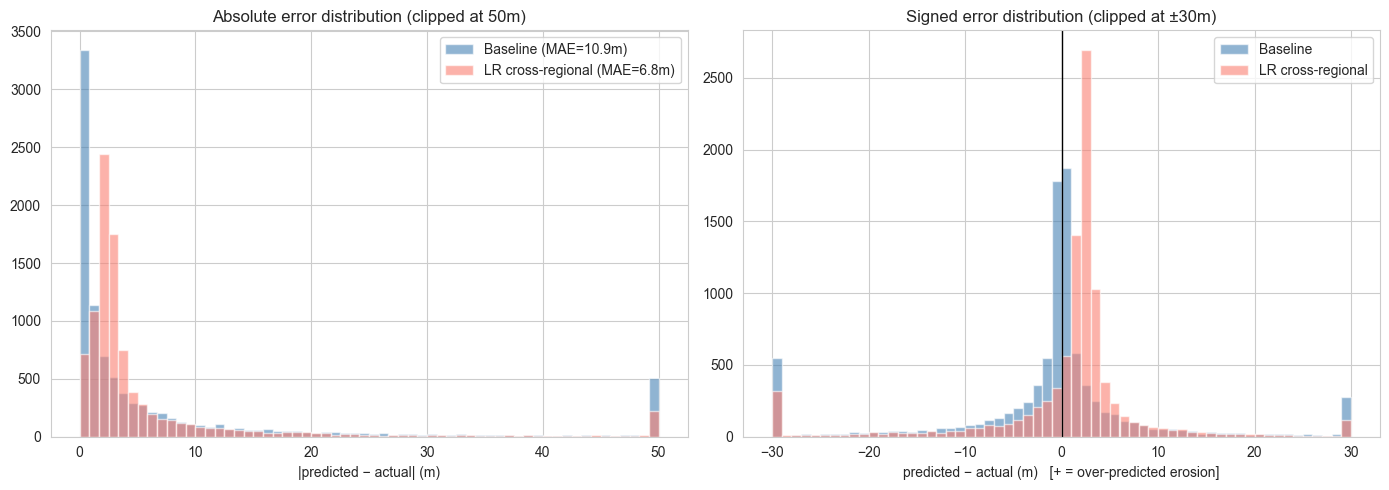

In [8]:
# Error distribution comparison
plot_error_distributions([
    {'label': 'Baseline',       'actual': eval_df['actual_dist'], 'predicted': eval_df['predicted_dist_baseline'], 'color': 'steelblue'},
    {'label': 'LR cross-regional', 'actual': eval_df['actual_dist'], 'predicted': eval_df['predicted_dist_lr'],   'color': 'salmon'},
])

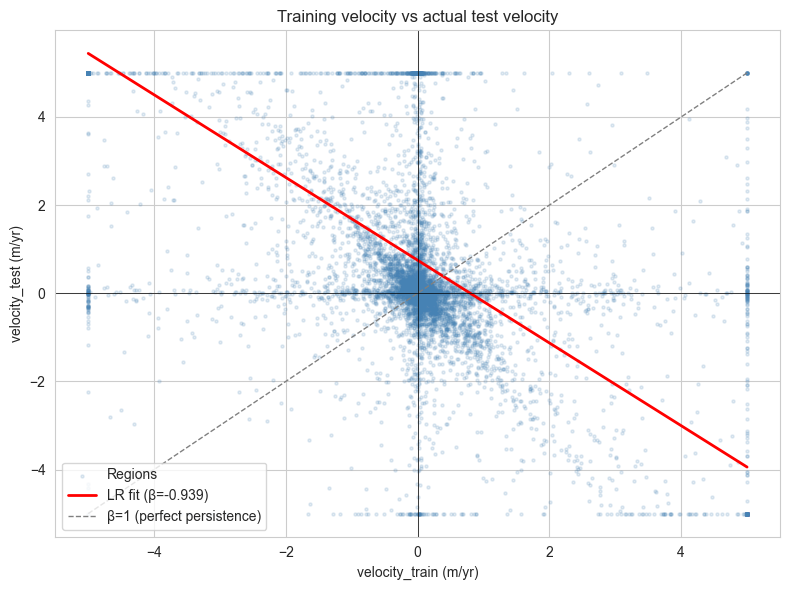

In [9]:
# Scatter: velocity_train vs velocity_test with regression line
clip = 5  # clip extreme velocities for readability
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    eval_df['velocity_train'].clip(-clip, clip),
    eval_df['velocity_test'].clip(-clip, clip),
    alpha=0.15, s=5, color='steelblue', label='Regions'
)
x_range = np.linspace(-clip, clip, 100)
ax.plot(x_range, lr.intercept_ + lr.coef_[0] * x_range, color='red', linewidth=2, label=f'LR fit (β={lr.coef_[0]:.3f})')
ax.plot(x_range, x_range, color='grey', linestyle='--', linewidth=1, label='β=1 (perfect persistence)')
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('velocity_train (m/yr)')
ax.set_ylabel('velocity_test (m/yr)')
ax.set_title('Training velocity vs actual test velocity')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Next steps

Potential improvements to try in this notebook:

- **+ cluster as feature** — `ijssel1` / `maas` / `rijn` etc. behave differently; 100m on the Waal ≠ 100m on the IJssel
- **+ distance_to_centerline** — proximity to river may predict erosion rate
- **+ bend type** — outer bends erode faster than inner bends
- **+ WFS features** — soil type, vegetation, land use (already on disk in `02_processed/wfs_context/`)
- **Non-linear models** — Random Forest, XGBoost on the same features
- **Proper cross-validation** — currently in-sample fit; use held-out regions for unbiased evaluation